# Variational Autoencoder with PyTorch 

In [1]:
pip install torch torchvision

  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/203.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/203.1 MB 4.2 MB/s eta 0:00:48
   ---------------------------------------- 1.0/203.1 MB 3.0 MB/s eta 0:01:09
   ---------------------------------------- 1.6/203.1 MB 3.1 MB/s eta 0:01:05
   ---------------------------------------- 1.8/203.1 MB 2.9 MB/s eta 0:01:10
   ---------------------------------------- 2.4/203.1 MB 2.6 MB/s eta 0:01:18
    --------------------------------------- 2.6/203.1 MB 2.3 MB/s eta 0:01:27
    --------------------------------------- 2.9/203.1 MB 2.2 MB/s eta 0:01:30
    ---------------------------


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\BOUKA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Imports 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/inputs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
from sklearn import preprocessing

# Any results you write to the current directory are saved as output.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Get a quick view of the data 

In [5]:
DATA_PATH = 'inputs/diabetes.csv'
df = pd.read_csv(DATA_PATH, sep=',').head()
df=df.dropna()
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## Process datasets

### Pima dataset

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns



In [29]:
DATA_PATH = 'inputs/diabetes.csv'
df = pd.read_csv(DATA_PATH, sep=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
df[df['Outcome']==1].info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               268 non-null    int64  
 1   Glucose                   268 non-null    int64  
 2   BloodPressure             268 non-null    int64  
 3   SkinThickness             268 non-null    int64  
 4   Insulin                   268 non-null    int64  
 5   BMI                       268 non-null    float64
 6   DiabetesPedigreeFunction  268 non-null    float64
 7   Age                       268 non-null    int64  
 8   Outcome                   268 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 20.9 KB


In [39]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#### Null Values

<Axes: >

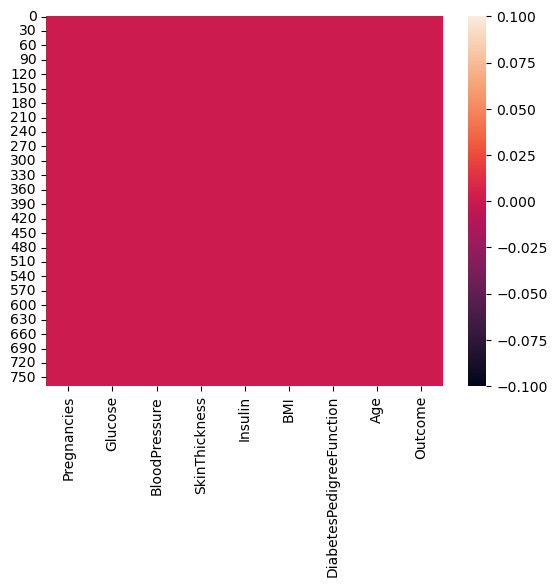

In [45]:
sns.heatmap(df.isnull())

In [67]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [63]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


* Those variables `Glucose`,`BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` have the value 0 as we can see the **min** value
* Instances with one or more of these variables having this wild observation should be deleted, because the 0 value in any of those variables is just not possible in the real world.

#### Cleansing the data: removing outliers

In [98]:
df=df[df['Glucose']!=0]

In [100]:
df = df[df['BloodPressure']!=0]

In [102]:
df = df[df['Insulin']!=0]

In [104]:
df = df[df['BMI']!=0]

In [106]:
df = df[df['SkinThickness']!=0]

In [114]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,3.301020,122.627551,70.663265,29.145408,156.056122,33.086224,0.523046,30.864796,0.331633
std,3.211424,30.860781,12.496092,10.516424,118.841690,7.027659,0.345488,10.200777,0.471401
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,21.000000,76.750000,28.400000,0.269750,23.000000,0.000000
50%,2.000000,119.000000,70.000000,29.000000,125.500000,33.200000,0.449500,27.000000,0.000000
75%,5.000000,143.000000,78.000000,37.000000,190.000000,37.100000,0.687000,36.000000,1.000000
max,17.000000,198.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [135]:
df['Outcome'].nunique
df['Outcome'].value_counts()

Outcome
0    262
1    130
Name: count, dtype: int64

* **There are two classes: 0 is 'Non Diabetes' and 1 is 'Diabetes'**

### Visualizations

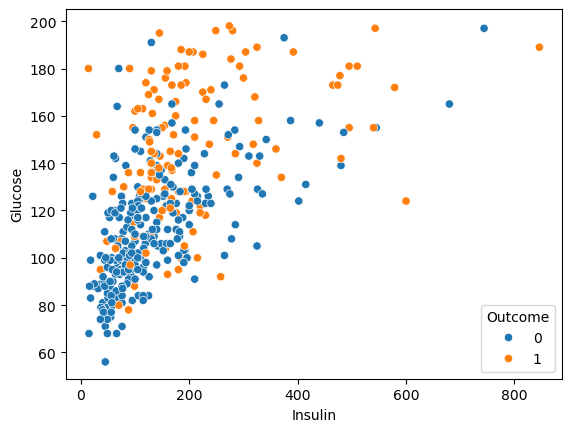

In [139]:
sns.scatterplot(data=df, x="Insulin", y="Glucose", hue ="Outcome")
plt.show()

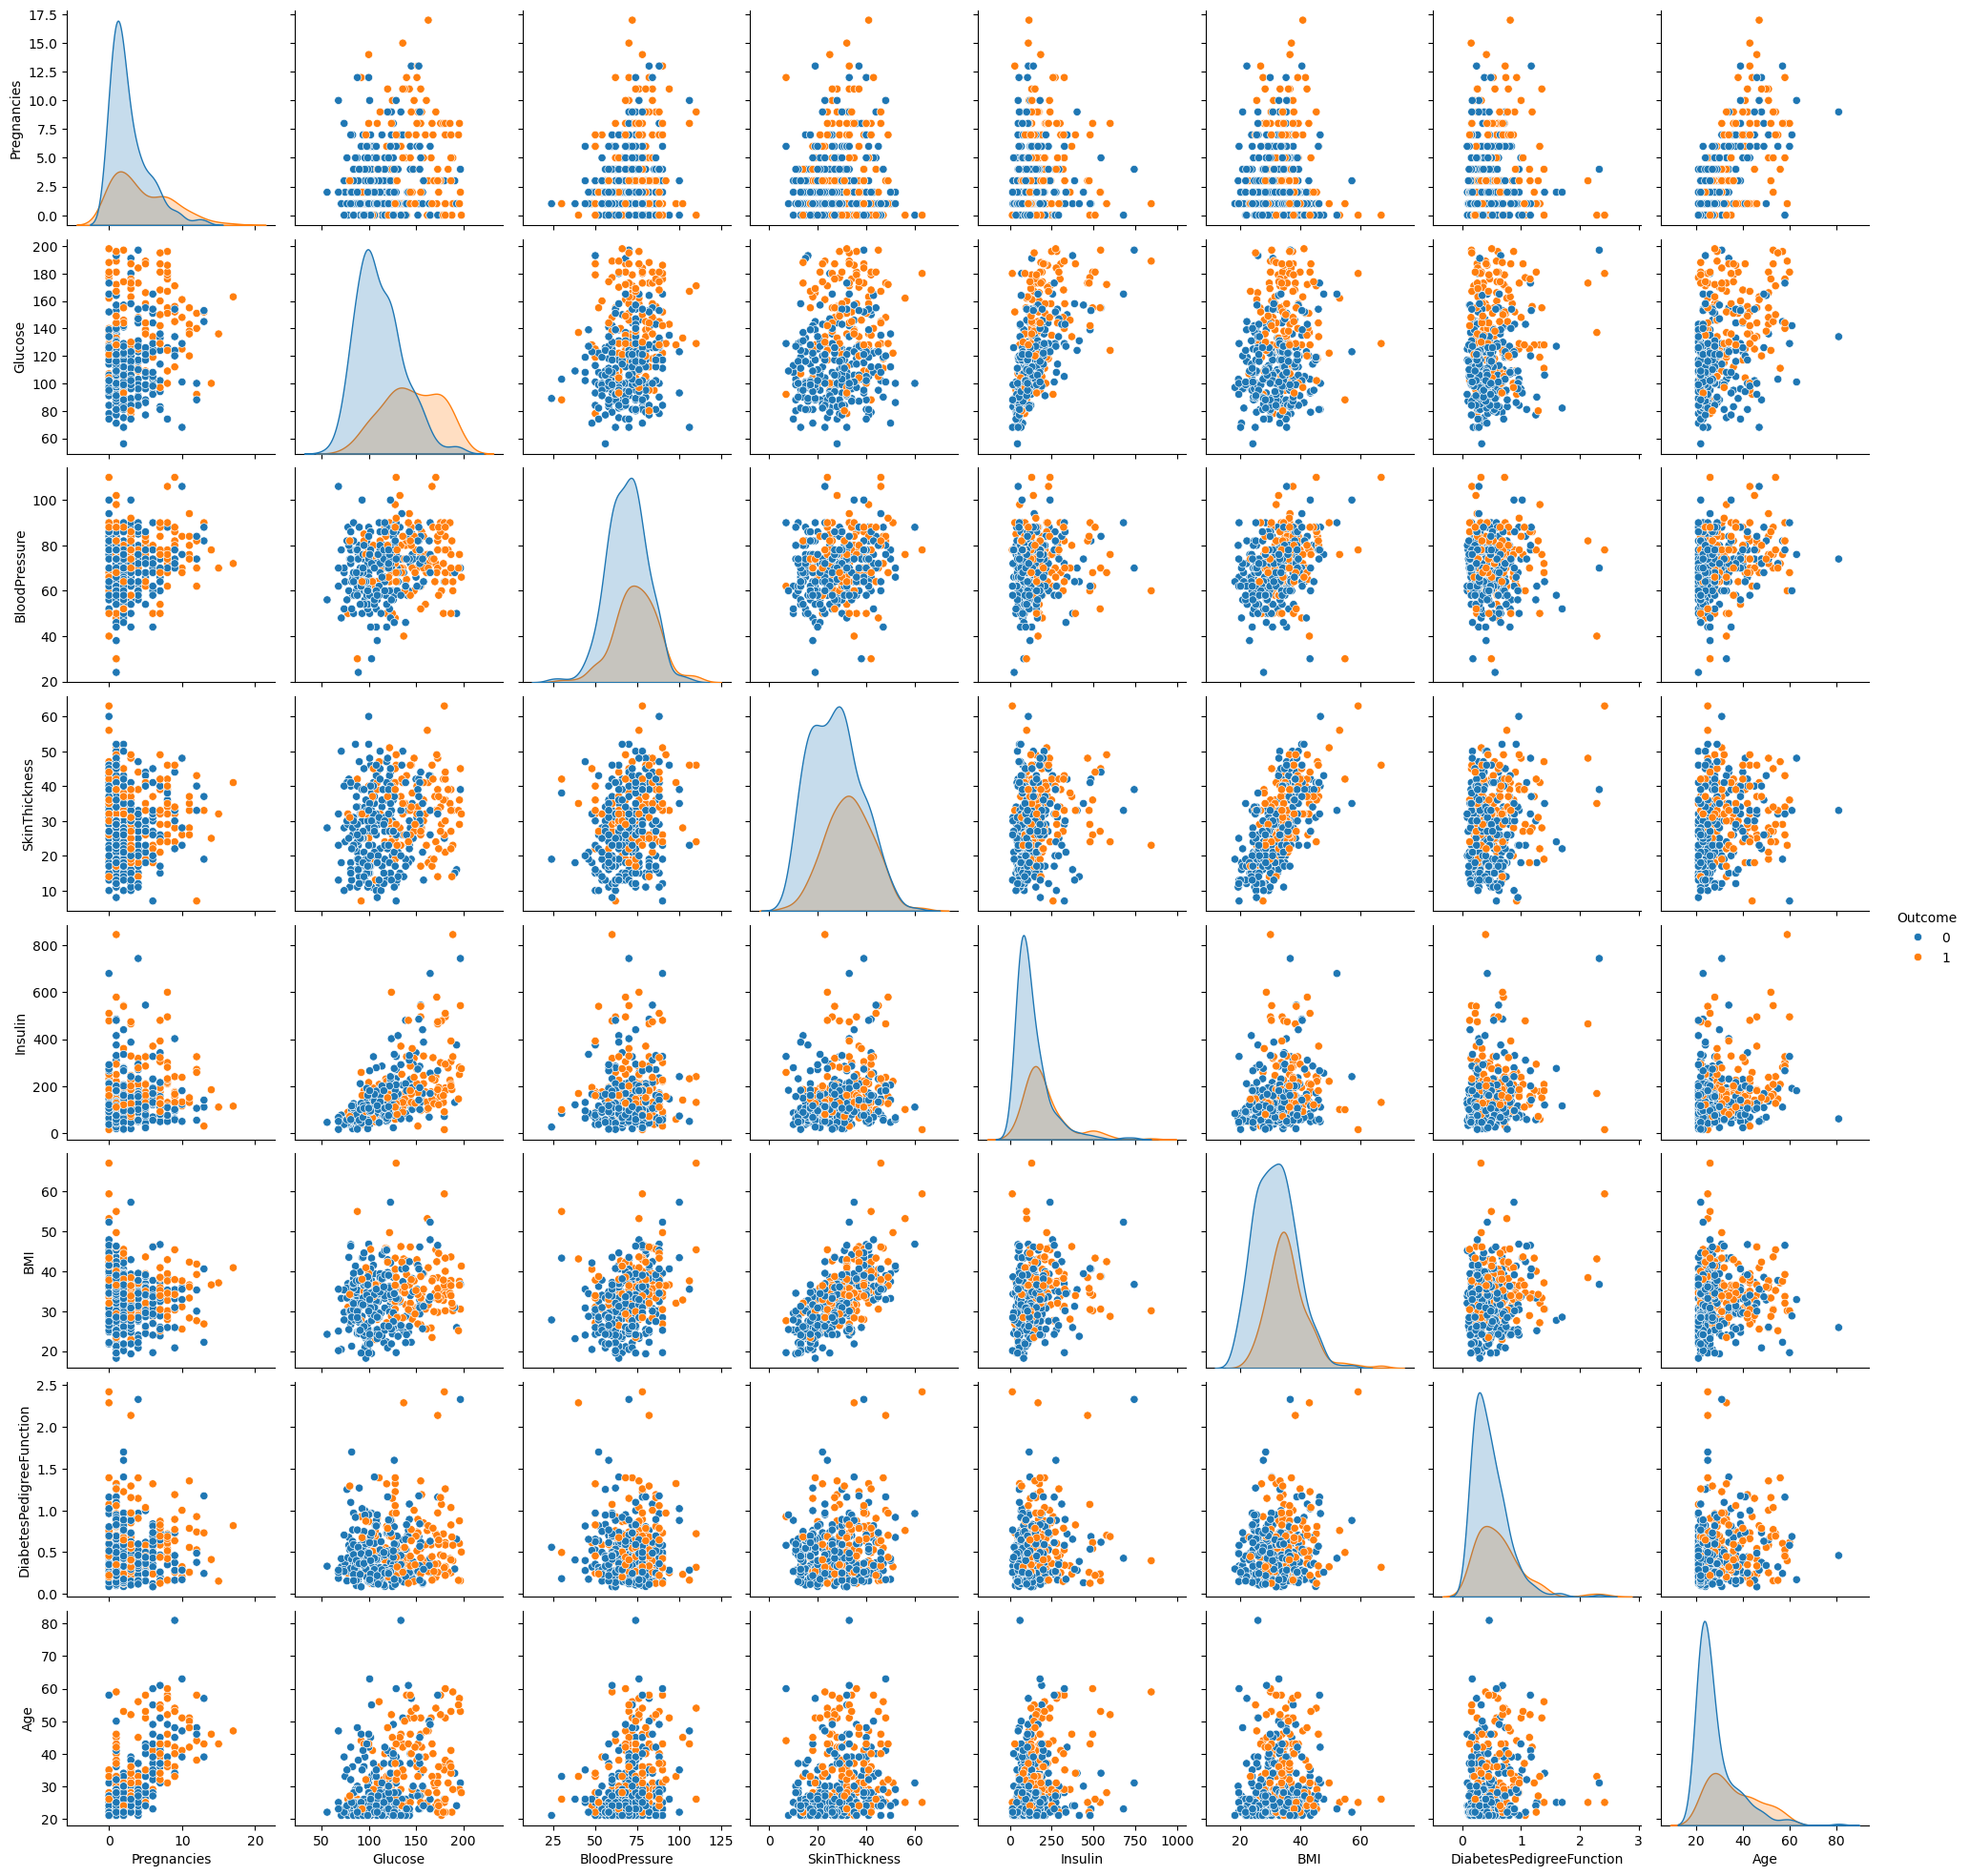

In [142]:
sns.pairplot(data=df, hue='Outcome')

* Glucose and the rest of variables as pairs could be dsicriminative

#### Spearman Rank Correlation

<Axes: >

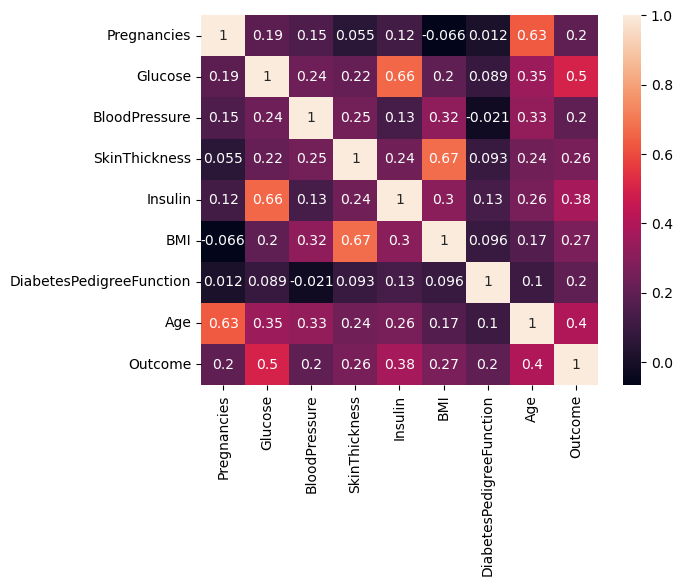

In [146]:
corr = df.corr(method="spearman")
sns.heatmap(corr,annot=True)

<Axes: xlabel='Pregnancies', ylabel='Outcome'>

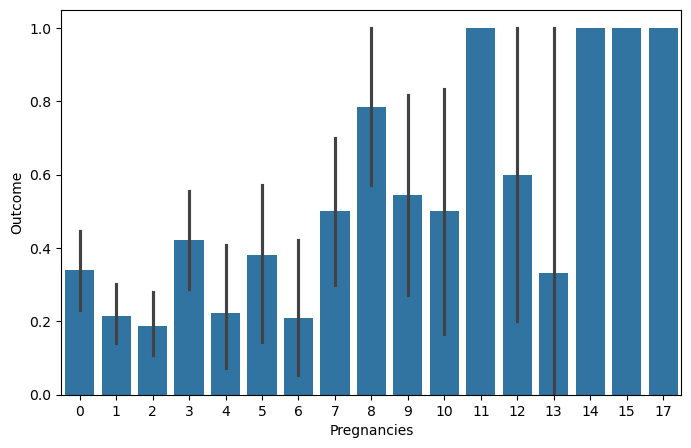

In [108]:
chart = plt.figure(figsize=(8,5))
sns.barplot(x="Pregnancies", y="Outcome", data=df)


* We drop outlier values using **IQR(Interquartile Range Method)**

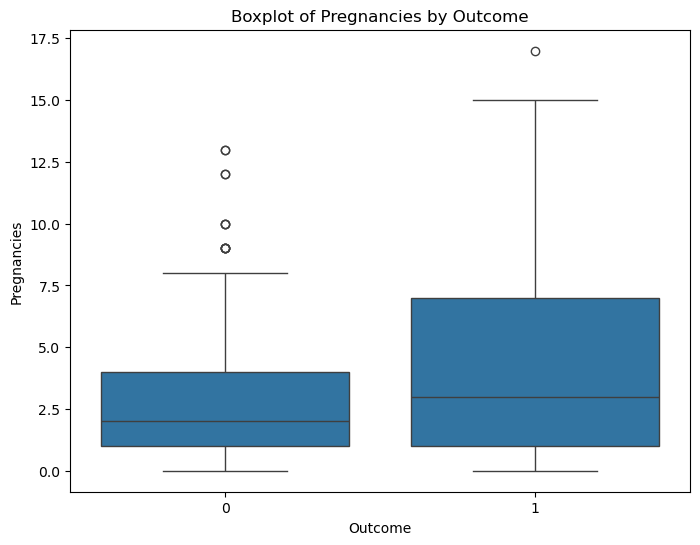

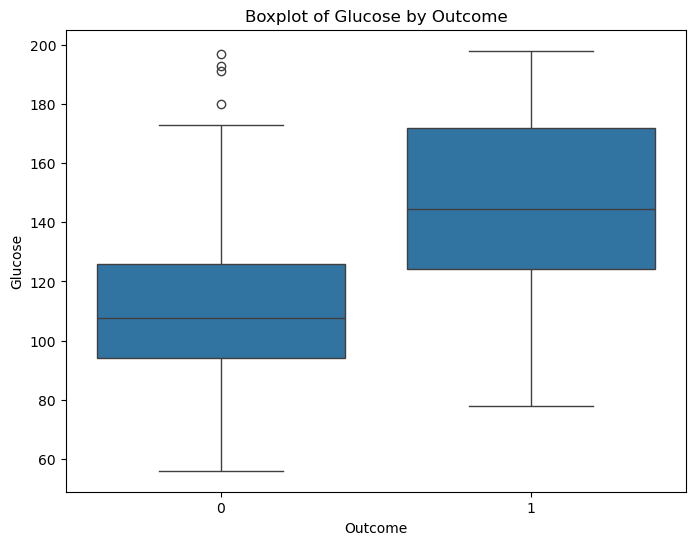

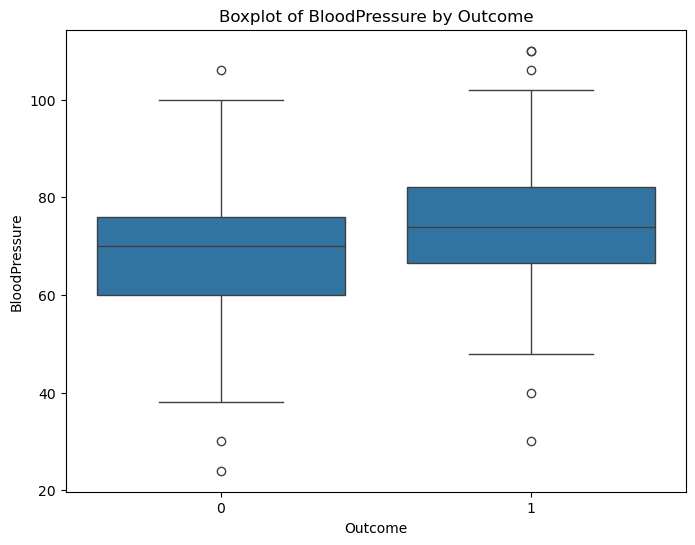

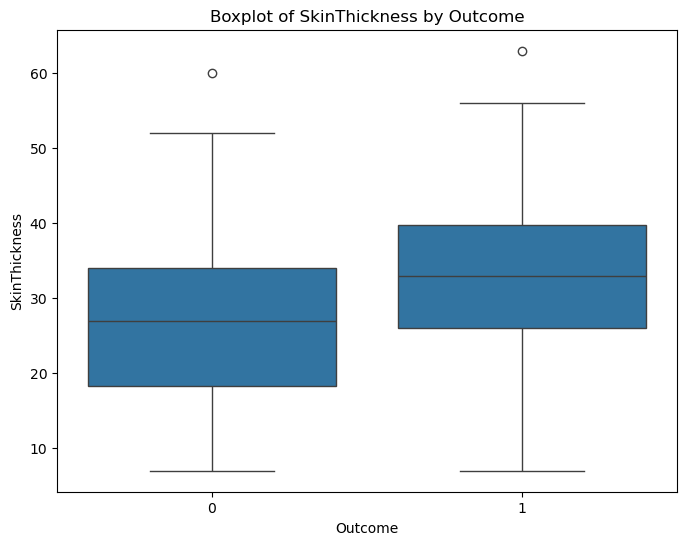

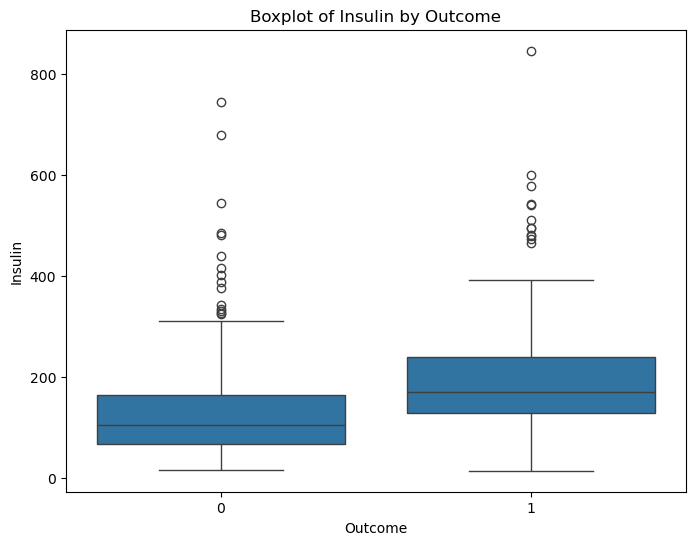

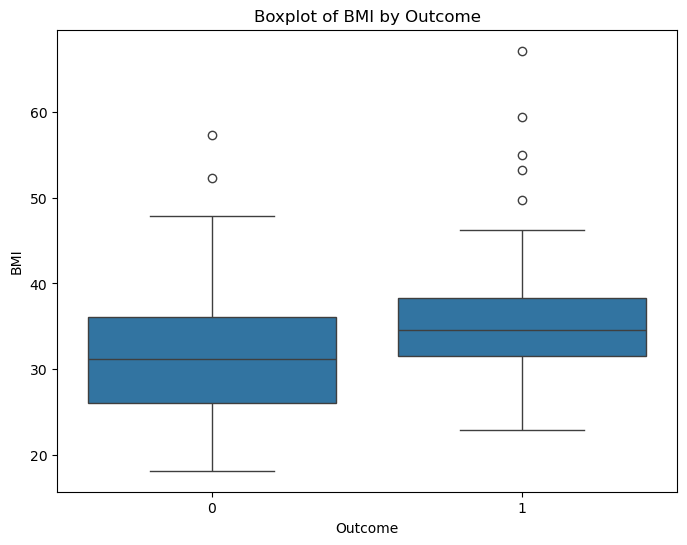

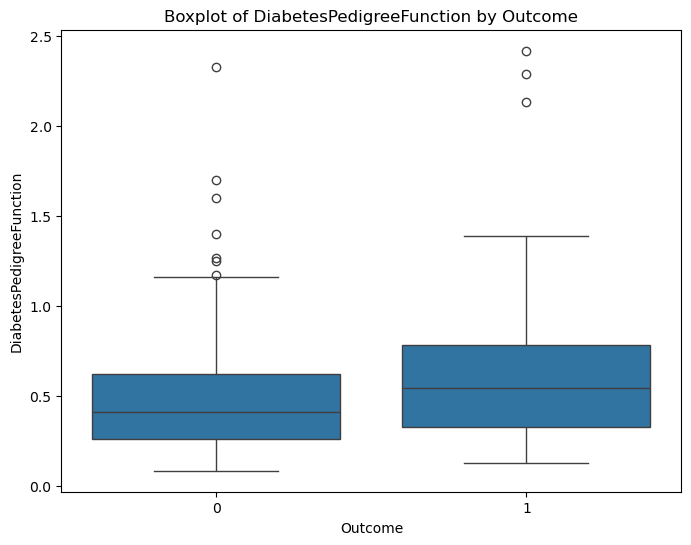

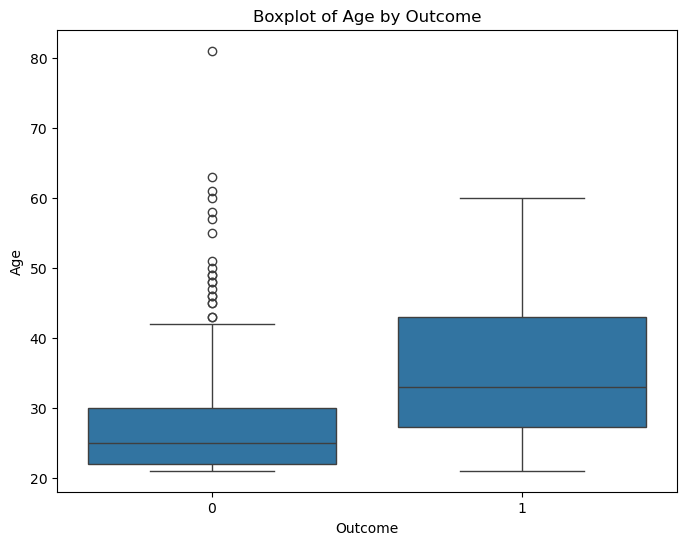

In [157]:
cols = [col for col in df.columns if col!="Outcome"]
for col in cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [188]:
def removeOutlier(col):
    sorted(col)
    quant1, quant2 = col.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lowerRange = quant1 - (1.5 * IQR)
    upperRange = quant2 + (1.5 * IQR)
    return lowerRange, upperRange

In [198]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,3.239796,122.627551,70.678571,29.140306,146.915497,32.975510,0.510568,30.700255,0.331633
std,3.027352,30.860781,12.085321,10.500430,90.206503,6.663895,0.298082,9.685334,0.471401
min,0.000000,56.000000,38.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,21.000000,76.750000,28.400000,0.269750,23.000000,0.000000
50%,2.000000,119.000000,70.000000,29.000000,125.500000,33.200000,0.449500,27.000000,0.000000
75%,5.000000,143.000000,78.000000,37.000000,190.000000,37.100000,0.687000,36.000000,1.000000
max,11.000000,198.000000,102.000000,61.000000,359.875000,50.150000,1.312875,55.500000,1.000000


In [200]:
for col in cols:
    lowScore, highScore = removeOutlier(df[col])
    print(f"Column: {col}, Lower Bound: {lowScore}, Upper Bound: {highScore}")
    df[col] = np.where(df[col]>highScore, highScore, df[col])
    df[col] = np.where(df[col]<lowScore, lowScore, df[col])

Column: Pregnancies, Lower Bound: -5.0, Upper Bound: 11.0
Column: Glucose, Lower Bound: 33.0, Upper Bound: 209.0
Column: BloodPressure, Lower Bound: 38.0, Upper Bound: 102.0
Column: SkinThickness, Lower Bound: -3.0, Upper Bound: 61.0
Column: Insulin, Lower Bound: -93.125, Upper Bound: 359.875
Column: BMI, Lower Bound: 15.349999999999994, Upper Bound: 50.150000000000006
Column: DiabetesPedigreeFunction, Lower Bound: -0.3561249999999999, Upper Bound: 1.312875
Column: Age, Lower Bound: 3.5, Upper Bound: 55.5


* **Check if the outliers are handled**

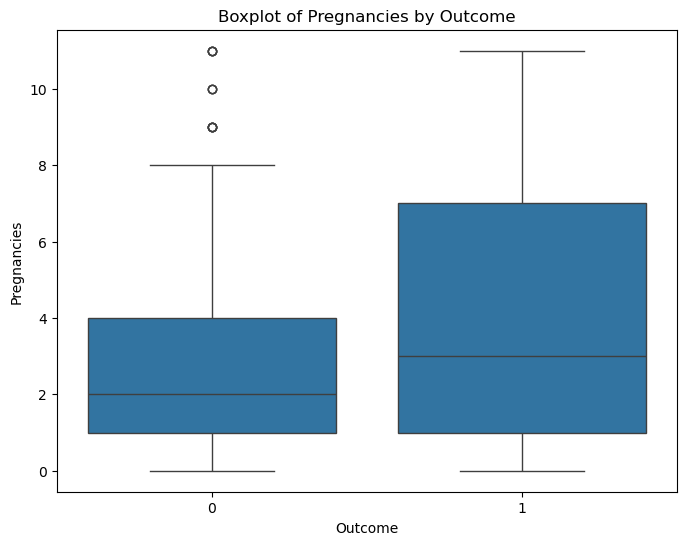

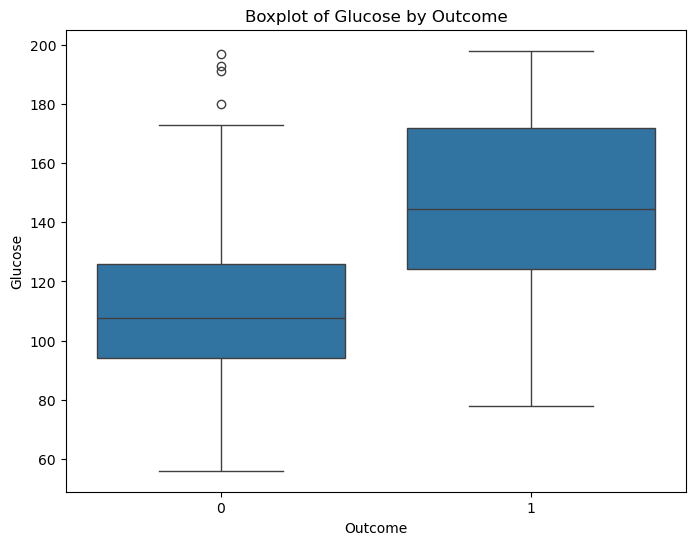

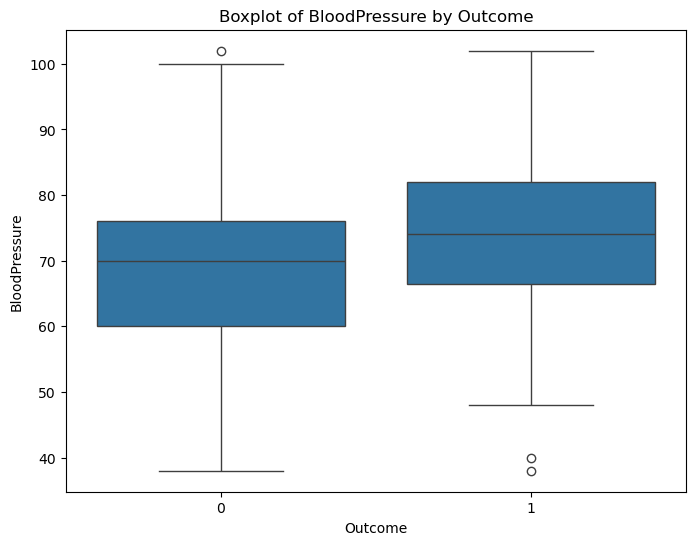

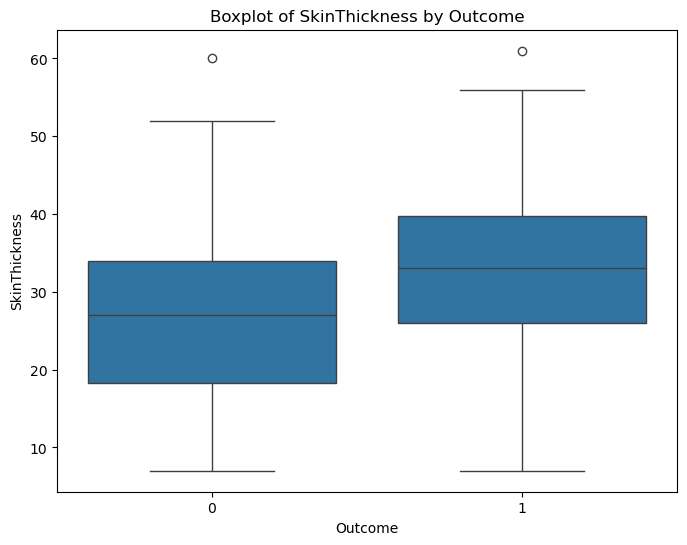

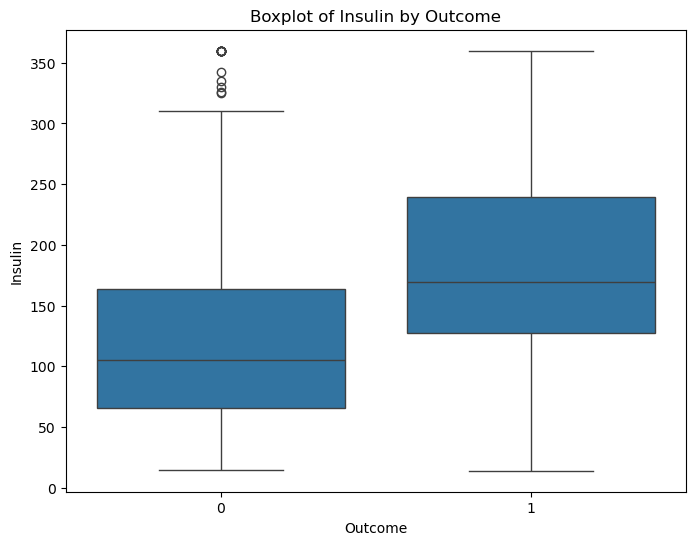

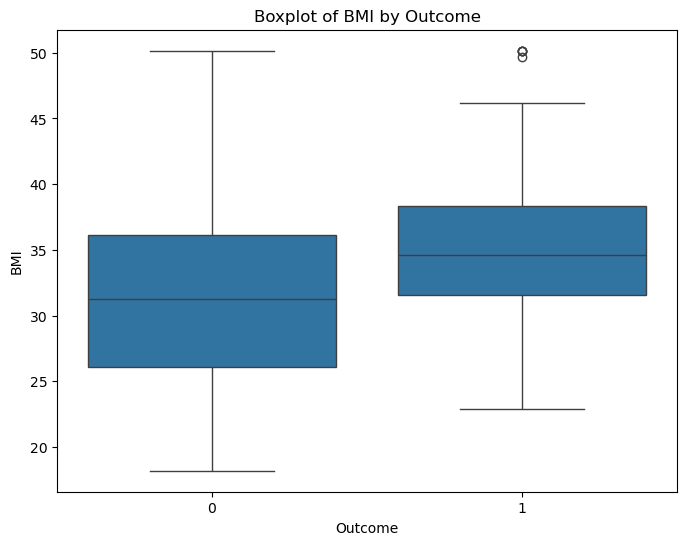

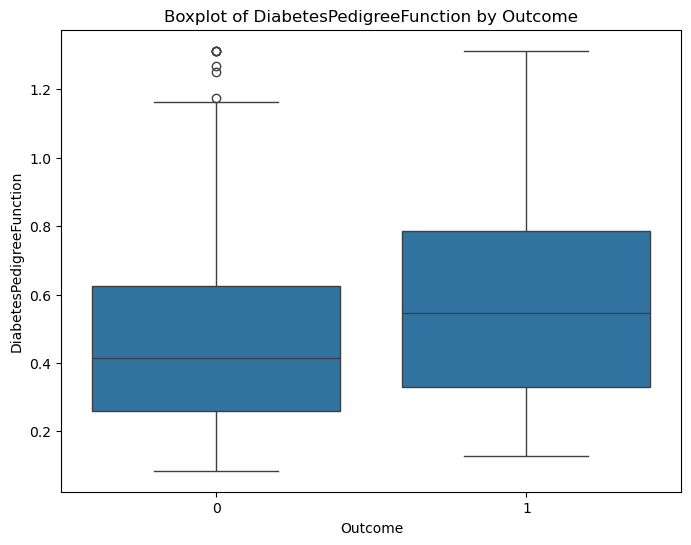

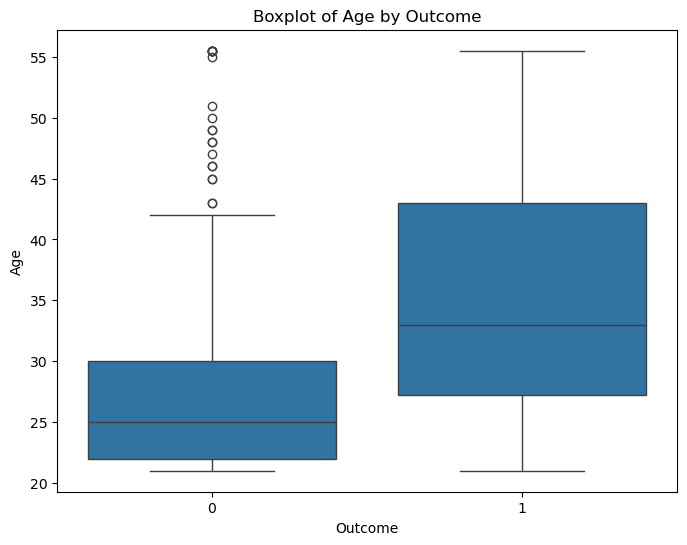

In [203]:
cols = [col for col in df.columns if col!="Outcome"]
for col in cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

### save the preprocessed dataset "Pima_processed.csv"

In [206]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1.0,89.0,66.0,23.0,94.000,28.1,0.167000,21.0,0
4,0.0,137.0,40.0,35.0,168.000,43.1,1.312875,33.0,1
6,3.0,78.0,50.0,32.0,88.000,31.0,0.248000,26.0,1
8,2.0,197.0,70.0,45.0,359.875,30.5,0.158000,53.0,1
13,1.0,189.0,60.0,23.0,359.875,30.1,0.398000,55.5,1


In [208]:
df.to_csv(path_or_buf="Pima_processed.csv")

### Preprocessing the dataset "Dermatology"

## Define Functions 

In [920]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_data(path_processed, test_size = test_size, random_state=random_state):
    # Read the data from a CSV file
    df = pd.read_csv(path_processed, sep=',')
    #df.drop('Pregnancies', axis=1, inplace=True)
    
    # Replace NaN values with a placeholder (e.g., -99)
    #df = df.dropna()
    
    # Separate features and labels
    df_base = df.iloc[:, :-1]  # Features
    df_labels = df.iloc[:, -1].values  # Labels
    # Split data into train and test sets using stratified random sampling
    X_train, X_test, y_train, y_test = train_test_split(
        df_base.values,
        df_labels,
        test_size=test_size,
        stratify=df_labels,
        random_state=random_state
    )
    
    
    # Fit the StandardScaler on training data and transform both train and test sets
    standardizer = StandardScaler()
    X_train = standardizer.fit_transform(X_train)  # Fit and transform training data
    X_test = standardizer.transform(X_test)       # Transform test data only
    
    # Identify majority and minority classes in the training set
    label_counts = pd.Series(y_train).value_counts()
    print(label_counts)
    minority_label = label_counts.idxmin()
    majority_label = label_counts.idxmax()

    # Calculate imbalance ratio
    minority_count = label_counts[minority_label]
    majority_count = label_counts[majority_label]
    imbalance_ratio = minority_count / majority_count
    
    # Separate the training data into majority and minority classes
    minority_data = X_train[y_train == minority_label]
    majority_data = X_train[y_train == majority_label]
    
    # Print imbalance ratio
    print(f"Imbalance Ratio (IR): {imbalance_ratio:.2f} (Majority: {majority_count}, Minority: {minority_count})")
    print(f"type of minority data: {type(minority_data)}")
    # Return train/test sets, scaler, and separated majority/minority data
    return X_train, y_train, X_test, y_test, standardizer, majority_data, minority_data, imbalance_ratio

def numpyToTensor(x):
    x_train = torch.from_numpy(x).to(device)
    return x_train

## Build Data Loader 

In [923]:
from torch.utils.data import Dataset, DataLoader
class DataBuilderMin(Dataset):
    def __init__(self, path):
        _,_,_,_, self.standardizer, _, self.x, _ = load_data(DATA_PATH)
        self.x = numpyToTensor(self.x)
        self.len=self.x.shape[0]
    def __getitem__(self,index):      
        return self.x[index]
    def __len__(self):
        return self.len

class DataBuilderMaj(Dataset):
    def __init__(self, path):
        _,_,_,_, self.standardizer, self.x, _, _ = load_data(DATA_PATH)
        self.x = numpyToTensor(self.x)
        self.len=self.x.shape[0]
    def __getitem__(self,index):      
        return self.x[index]
    def __len__(self):
        return self.len

## Build Model and train it

Usually VAE are used for Image processing and creating (like GANS Models). This is explained here: https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73
However, we can adapt this approach to use it on tabular data. This way the Autoencoder helps us reducing dimensionality of data and also reduce noise.

In [927]:
# Initialize the H=H, H2=H2, latent_dim=latent_dim

class Autoencoder(nn.Module):
    def __init__(self,D_in,H=60,H2=30,latent_dim=6):
        
        #Encoder
        super(Autoencoder,self).__init__()
        self.linear1=nn.Linear(D_in,H)
        self.lin_bn1 = nn.BatchNorm1d(num_features=H)
        self.linear2=nn.Linear(H,H2)
        self.lin_bn2 = nn.BatchNorm1d(num_features=H2)
        self.linear3=nn.Linear(H2,H2)
        self.lin_bn3 = nn.BatchNorm1d(num_features=H2)
        
#         # Latent vectors mu and sigma
        self.fc1 = nn.Linear(H2, latent_dim)
        self.bn1 = nn.BatchNorm1d(num_features=latent_dim)
        self.fc21 = nn.Linear(latent_dim, latent_dim)
        self.fc22 = nn.Linear(latent_dim, latent_dim)

#         # Sampling vector
        self.fc3 = nn.Linear(latent_dim, latent_dim)
        self.fc_bn3 = nn.BatchNorm1d(latent_dim)
        self.fc4 = nn.Linear(latent_dim, H2)
        self.fc_bn4 = nn.BatchNorm1d(H2)
        
#         # Decoder
        self.linear4=nn.Linear(H2,H2)
        self.lin_bn4 = nn.BatchNorm1d(num_features=H2)
        self.linear5=nn.Linear(H2,H)
        self.lin_bn5 = nn.BatchNorm1d(num_features=H)
        self.linear6=nn.Linear(H,D_in)
        self.lin_bn6 = nn.BatchNorm1d(num_features=D_in)
        
        self.relu = nn.ReLU()
        
    def encode(self, x):
        lin1 = self.relu(self.lin_bn1(self.linear1(x)))
        lin2 = self.relu(self.lin_bn2(self.linear2(lin1)))
        lin3 = self.relu(self.lin_bn3(self.linear3(lin2)))

        fc1 = F.relu(self.bn1(self.fc1(lin3)))

        r1 = self.fc21(fc1)
        r2 = self.fc22(fc1)
        
        return r1, r2
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = logvar.mul(0.5).exp_()
            eps = Variable(std.data.new(std.size()).normal_())
            return eps.mul(std).add_(mu)
        else:
            return mu
        
    def decode(self, z):
        fc3 = self.relu(self.fc_bn3(self.fc3(z)))
        fc4 = self.relu(self.fc_bn4(self.fc4(fc3)))

        lin4 = self.relu(self.lin_bn4(self.linear4(fc4)))
        lin5 = self.relu(self.lin_bn5(self.linear5(lin4)))
        return self.lin_bn6(self.linear6(lin5))


        
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        # self.decode(z) ist später recon_batch, mu ist mu und logvar ist logvar
        return self.decode(z), mu, logvar


class customLoss(nn.Module):
    def __init__(self):
        super(customLoss, self).__init__()
        self.mse_loss = nn.MSELoss(reduction="sum")
    
    # x_recon ist der im forward im Model erstellte recon_batch, x ist der originale x Batch, mu ist mu und logvar ist logvar 
    def forward(self, x_recon, x, mu, logvar):
        #print(f"type of x_recon is {type(x_recon)}")
        #print(f"type of x is {type(x)}")
        loss_MSE = self.mse_loss(x_recon, x) #/ x.numel() 
        loss_KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # Normalize by batch size

        return loss_MSE +  loss_KLD

# takes in a module and applies the specified weight initialization
def weights_init_uniform_rule(m):
    classname = m.__class__.__name__
    # for every Linear layer in a model..
    if classname.find('Linear') != -1:
        # get the number of the inputs
        n = m.in_features
        y = 1.0/np.sqrt(n)
        m.weight.data.uniform_(-y, y)
        m.bias.data.fill_(0)

# Train Model 

## Train Model on Minority class

In [931]:
def train(epoch, trainloader=trainloader_min):
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(trainloader):
        #data = data.to(device)
        data = data.to(device).float()
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_mse(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
#        if batch_idx % log_interval == 0:
#            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
#                epoch, batch_idx * len(data), len(trainloader.dataset),
#                       100. * batch_idx / len(trainloader),
#                       loss.item() / len(data)))
    if epoch % log_interval == 0:        
        print('====> Epoch: {} Average loss: {:.4f}'.format(
            epoch, train_loss / len(trainloader.dataset)))
        train_losses.append(train_loss / len(trainloader.dataset))

In [969]:
test_size = 0.2
random_states = [i for i in np.random.randint(0,1000,  size=30)]
print(random_states)
#random_state = 200
#---------------modify here-----------#
H=100
H2=50
latent_dim=3
epochs = 500
batch_size=50
learning_rate = 1e-3 # we tested 1e-3
#---------------stable---------------#
log_interval = 10
dict_r = {}
for rand_state in random_states:
    random_state=rand_state
    X_train, y_train, X_test, y_test, standardizer, majority_data, minority_data, imbalance_ratio = load_data(DATA_PATH, test_size=test_size, random_state=random_state)

    n_min = minority_data.shape[0]
    n_maj = majority_data.shape[0] 
    # Majority data augmentation ratio
    prop_SD_maj = 0

    # Imbalance Ratio
    IR_new = np.round((1+prop_SD_maj)*n_maj/(n_min),2)
    # proportion of Minority  synthetic data
    prop_SD_min = (IR_new-1)

    # Number of Synthetic Data to sample (SD)
    n_SD_min = int(n_min * prop_SD_min)
    n_SD_maj =  int(n_maj * prop_SD_maj)
    print(f"Number of minority data to sample is {prop_SD_min} = {n_SD_min} with a IR of {IR_new}  ")
    Minority_data=DataBuilderMin(DATA_PATH)
    Majority_data=DataBuilderMaj(DATA_PATH)

    trainloader_min=DataLoader(dataset=Minority_data,batch_size=batch_size)
    trainloader_maj = DataLoader(dataset=Majority_data,batch_size=batch_size)
    D_in = minority_data.shape[1]
    model = Autoencoder(D_in, H, H2).to(device)
    model.apply(weights_init_uniform_rule)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_mse = customLoss()
    val_losses = []
    train_losses = []
    for epoch in range(1, epochs + 1):
        train(epoch, trainloader = trainloader_min)
    # Set the model to evaluation mode
    model.eval()

    # Number of synthetic samples to generate
    num_samples = n_SD_min

    # Latent space dimensionality (from the VAE model architecture)
    latent_dim = model.fc1.out_features  # Latent dimension size

    # Generate random samples from the latent space
    z = torch.randn(num_samples, latent_dim).to(device)  # Random points from N(0, 1)

    # Decode the samples to generate synthetic data
    with torch.no_grad():  # No need to compute gradients
        synthetic_data = model.decode(z)

    # Convert synthetic data to a NumPy array (optional)
    synthetic_data_np = synthetic_data.cpu().numpy()
    x_synthetic_min = synthetic_data_np
    y_synthetic_min = np.ones(x_synthetic_min.shape[0], dtype = np.int8)
    x_min_diabetes_basicVAE = pd.DataFrame(x_synthetic_min, columns = list(df.columns)[:-1])
    x_min_diabetes_basicVAE['Outcome'] = y_synthetic_min
    # Prepare balanced training data
    tr_data = pd.DataFrame(X_train, columns= list(df.columns)[:-1] )
    tr_data['Outcome'] = y_train

    train_data = pd.concat([tr_data, SD_min])

    # Train Random Forest Classifier
    x_tr = train_data.iloc[:, :-1]
    y_tr = train_data.iloc[:, -1]
    rf = RandomForestClassifier(random_state=random_state,n_estimators=1000)
    rf.fit(x_tr, y_tr)
    x_test=pd.DataFrame(X_test, columns=list(df.columns)[:-1])
    # Evaluate the trained model on test data
    preds = rf.predict(x_test)
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f" for random_state= {random_state} \n acc = {acc}\n rec = {rec}\n f1 = {f1}")
    dict_r[random_state] = [acc, rec, f1] 

[50, 315, 383, 454, 289, 444, 113, 511, 364, 730, 579, 915, 449, 732, 898, 183, 489, 348, 478, 104, 723, 860, 535, 164, 614, 702, 498, 498, 224, 838]
0    400
1    214
Name: count, dtype: int64
Imbalance Ratio (IR): 0.54 (Majority: 400, Minority: 214)
type of minority data: <class 'numpy.ndarray'>
Number of minority data to sample is 0.8700000000000001 = 186 with a IR of 1.87  
0    400
1    214
Name: count, dtype: int64
Imbalance Ratio (IR): 0.54 (Majority: 400, Minority: 214)
type of minority data: <class 'numpy.ndarray'>
0    400
1    214
Name: count, dtype: int64
Imbalance Ratio (IR): 0.54 (Majority: 400, Minority: 214)
type of minority data: <class 'numpy.ndarray'>
====> Epoch: 10 Average loss: 14.0619
====> Epoch: 20 Average loss: 11.5768
====> Epoch: 30 Average loss: 10.7626
====> Epoch: 40 Average loss: 9.8353
====> Epoch: 50 Average loss: 9.2642
====> Epoch: 60 Average loss: 8.6967
====> Epoch: 70 Average loss: 8.2556
====> Epoch: 80 Average loss: 7.8463
====> Epoch: 90 Averag

 for random_state= 200 
 acc = 0.8181818181818182
 rec = 0.7407407407407407
 f1 = 0.7407407407407407

In [949]:
res_1 = pd.DataFrame.from_dict(data=dict_r)
res_1.head()

,521,187,6066,2017,8820,7514,9747,7472,7151,2530,...,9483,3648,2097,5806,7667,3813,8923,6702,7630,9798
0,0.779221,0.74026,0.766234,0.733766,0.785714,0.733766,0.688312,0.779221,0.766234,0.766234,...,0.727273,0.785714,0.772727,0.74026,0.779221,0.753247,0.753247,0.766234,0.740260,0.798701
1,0.703704,0.62963,0.648148,0.574074,0.666667,0.500000,0.500000,0.629630,0.611111,0.611111,...,0.537037,0.648148,0.611111,0.62963,0.537037,0.666667,0.666667,0.611111,0.574074,0.574074
2,0.690909,0.62963,0.660377,0.601942,0.685714,0.568421,0.529412,0.666667,0.647059,0.647059,...,0.580000,0.679612,0.653465,0.62963,0.630435,0.654545,0.654545,0.647059,0.607843,0.666667


In [963]:
res_1.to_excel("results_run_1.xlsx")

In [266]:
D_in = majority_data.shape[1]

model = Autoencoder(D_in, H, H2).to(device)
model.apply(weights_init_uniform_rule)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [268]:
loss_mse = customLoss()

In [160]:

val_losses = []
train_losses = []

In [162]:
def train(epoch, trainloader=trainloader_maj):
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(trainloader):
        #data = data.to(device)
        data = data.to(device).float()
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_mse(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
#        if batch_idx % log_interval == 0:
#            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
#                epoch, batch_idx * len(data), len(trainloader.dataset),
#                       100. * batch_idx / len(trainloader),
#                       loss.item() / len(data)))
    if epoch % log_interval == 0:        
        print('====> Epoch: {} Average loss: {:.4f}'.format(
            epoch, train_loss / len(trainloader.dataset)))
        train_losses.append(train_loss / len(trainloader.dataset))

In [164]:
for epoch in range(1, epochs + 1):
    train(epoch, trainloader = trainloader_maj)

====> Epoch: 50 Average loss: 6.4023
====> Epoch: 100 Average loss: 5.6126
====> Epoch: 150 Average loss: 5.2833
====> Epoch: 200 Average loss: 5.3001
====> Epoch: 250 Average loss: 5.1297
====> Epoch: 300 Average loss: 5.0643
====> Epoch: 350 Average loss: 4.9373
====> Epoch: 400 Average loss: 5.0208
====> Epoch: 450 Average loss: 5.0510
====> Epoch: 500 Average loss: 4.9164
====> Epoch: 550 Average loss: 4.8999
====> Epoch: 600 Average loss: 4.9276
====> Epoch: 650 Average loss: 4.9277
====> Epoch: 700 Average loss: 4.8369
====> Epoch: 750 Average loss: 4.8233
====> Epoch: 800 Average loss: 4.8659
====> Epoch: 850 Average loss: 4.7221
====> Epoch: 900 Average loss: 4.8967
====> Epoch: 950 Average loss: 4.6785
====> Epoch: 1000 Average loss: 4.8112
====> Epoch: 1050 Average loss: 4.6177
====> Epoch: 1100 Average loss: 4.7724
====> Epoch: 1150 Average loss: 4.5974
====> Epoch: 1200 Average loss: 4.6956
====> Epoch: 1250 Average loss: 4.7052
====> Epoch: 1300 Average loss: 4.5778
====> 

In [104]:
import torch

# Set the model to evaluation mode
model.eval()

# n_min , n_maj, IR
# SD_min = n_min * [(1-IR)+ 0.1]
# SD_maj = n_maj * (0.1)
# Number of synthetic samples to generate
num_samples = n_SD_maj

# Latent space dimensionality (from the VAE model architecture)
latent_dim = model.fc1.out_features  # Latent dimension size

# Generate random samples from the latent space
z = torch.randn(num_samples, latent_dim).to(device)  # Random points from N(0, 1)

# Decode the samples to generate synthetic data
with torch.no_grad():  # No need to compute gradients
    synthetic_data = model.decode(z)

# Convert synthetic data to a NumPy array (optional)
synthetic_data_np = synthetic_data.cpu().numpy()

print("Generated Synthetic Minority Data Shape:", synthetic_data_np.shape)


Generated Synthetic Minority Data Shape: (0, 8)


In [106]:
# Save Synthetic Majority data
# Save Minority synthetic data
x_synthetic_maj = synthetic_data_np
y_synthetic_maj = np.zeros(x_synthetic_maj.shape[0], dtype = np.int8)
x_maj_diabetes_basicVAE = pd.DataFrame(x_synthetic_maj, columns = list(df.columns)[:-1])
x_maj_diabetes_basicVAE['Outcome'] = y_synthetic_maj
x_maj_diabetes_basicVAE.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [277]:
#x_maj_diabetes_basicVAE.to_csv("SD_diabetes_maj_basicVAE.csv", index=False)

In [280]:
#standardizer = trainloader.dataset.standardizer